In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent, cwd / 'project_1']
PROJECT_ROOT = next(
    (path for path in candidates if (path / 'pyproject.toml').is_file()),
)

if PROJECT_ROOT is None:
    raise RuntimeError(f'Could not locate project_1 from {cwd}')

SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
    
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
SAVE_FIGURES = False

from tma4215_project1.functions import f, g, runge

 change funciton plots to use test funciton not runge

# a) Global Lagrange interpolation

In [2]:
from tma4215_project1.analysis.plots.lagrange_plots import (
    plot_chebyshev_equidistant_lagrange,
    plot_multiple_n_lagrange,
)

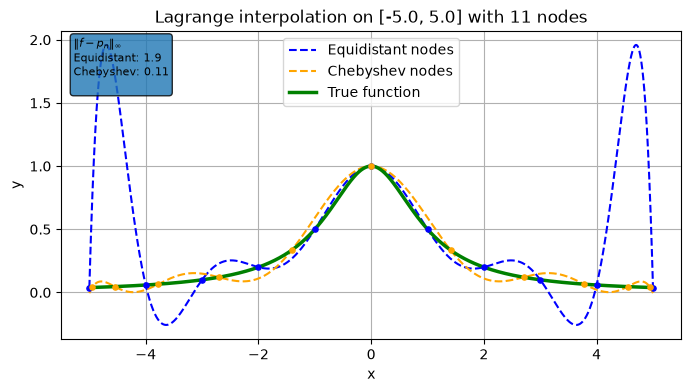

In [3]:
interval_a_wide = (-5.0, 5.0)

fig, ax = plot_chebyshev_equidistant_lagrange (
    fun = runge,
    interval = interval_a_wide,
    n = 10,
    points = 5001,
    savefig = SAVE_FIGURES,
)

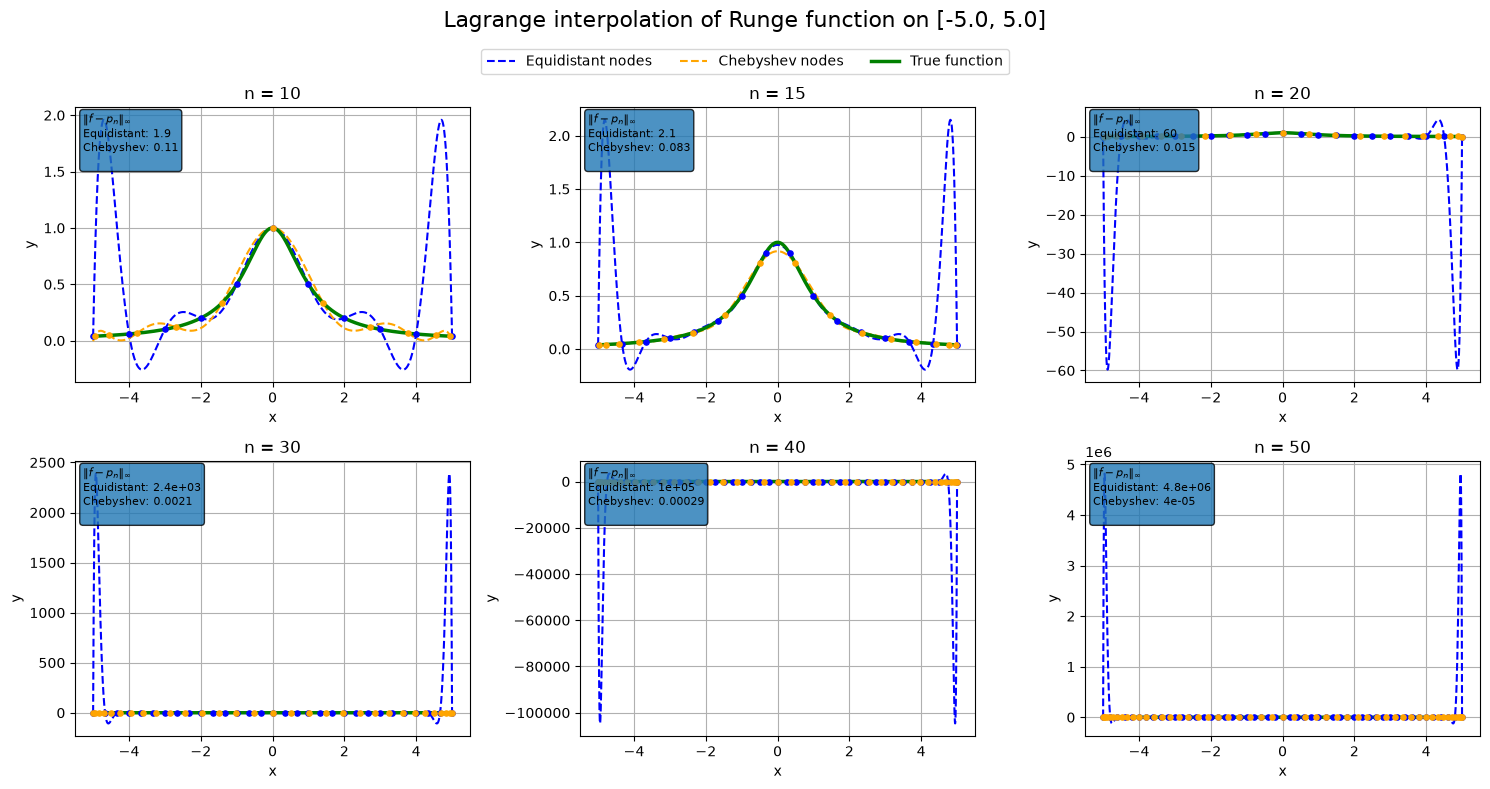

In [4]:
n_arr_a = np.array([10, 15, 20, 30, 40, 50], dtype = np.int64)

fig, axs = plot_multiple_n_lagrange(
    fun = runge,
    interval = interval_a_wide,
    n_arr = n_arr_a,
    points = 5001,
    savefig = SAVE_FIGURES,
)
plt.show()

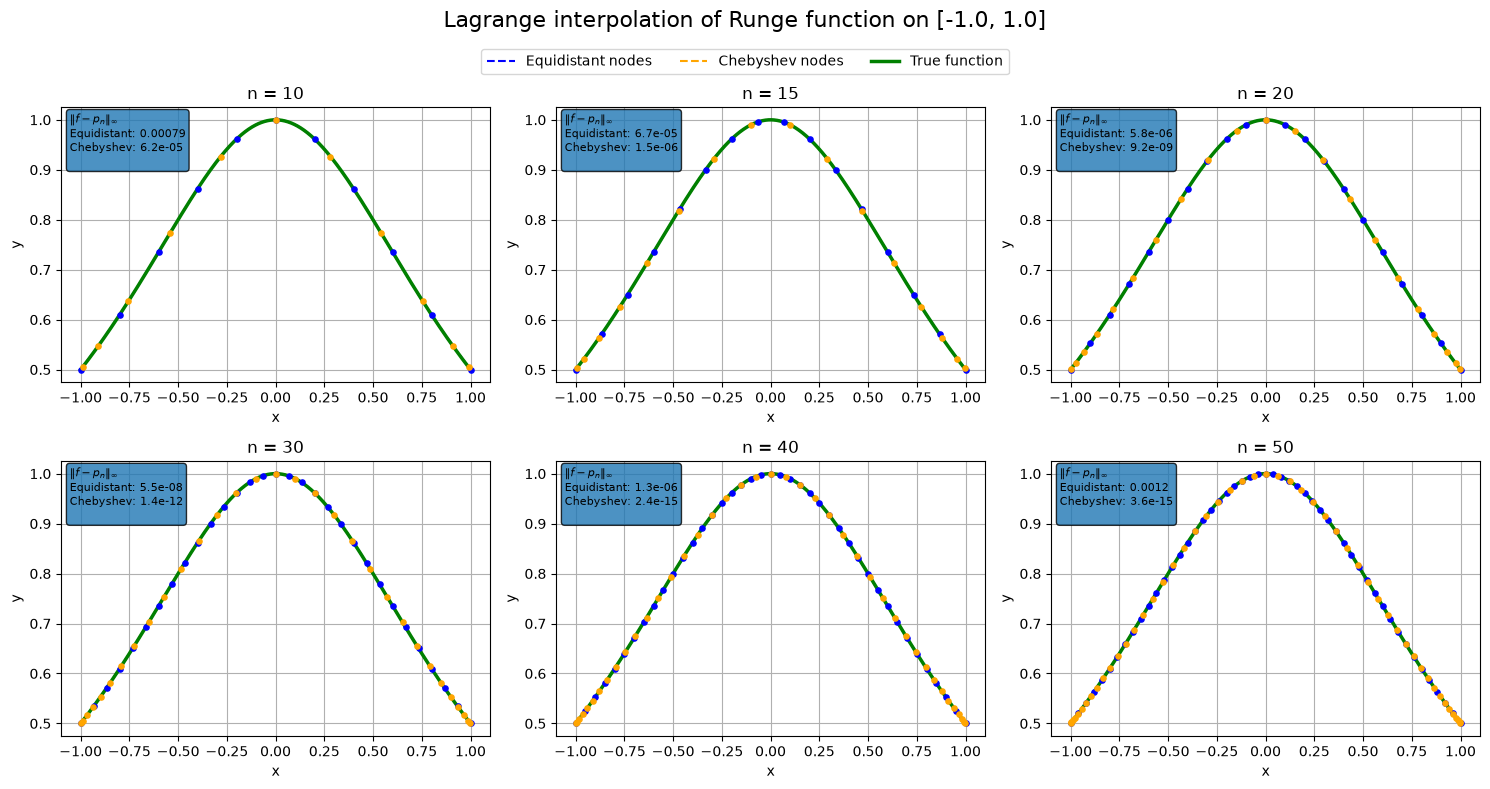

In [5]:
interval_a_small = (-1.0, 1.0)

fig, axs = plot_multiple_n_lagrange(
    fun = runge,
    interval = interval_a_small,
    n_arr = n_arr_a,
    points = 5001,
    savefig = SAVE_FIGURES,
)
plt.show()

# b) Error convergence and interpolation bounds

# Doble antall ledd per: 2^(n+1) ledd. Hvert ledd mindre enn 3^(n+1)2^(n+1)e^3x sin(2x)

In [6]:
from tma4215_project1.analysis.computations.lagrange_computations import(
    lagrange_error_norms_multiple_n,
)
from tma4215_project1.analysis.plots.lagrange_plots import(
    compare_l2_max_norm,
)

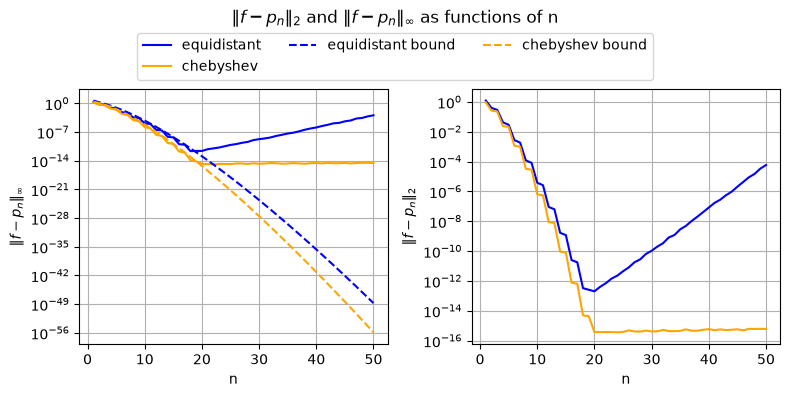

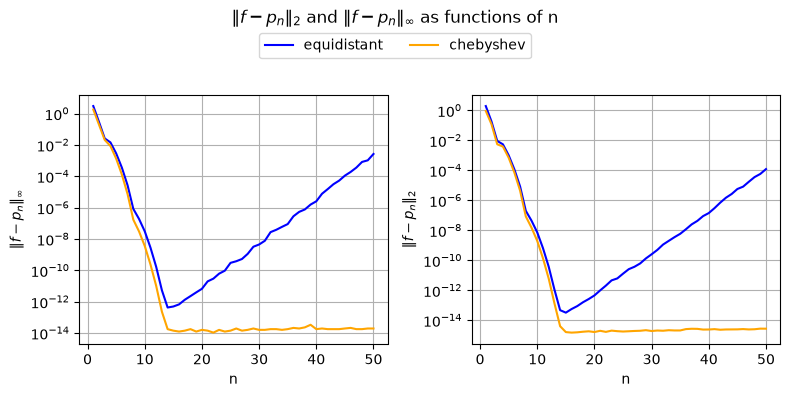

In [7]:
n_arr_b = np.arange(1, 51, dtype = np.int64)

fig, axs = compare_l2_max_norm(
    fun = f,
    interval = (0.0, 1.0),
    n_arr = n_arr_b,
    bound = True,
    use_numeric_calc = True,
    savefig = SAVE_FIGURES,
)
plt.show()

fig, axs = compare_l2_max_norm(
    fun = g,
    interval = (0.0, np.pi / 4),
    n_arr = n_arr_b,
    bound = False,
    savefig = SAVE_FIGURES,
)
plt.show()

In [8]:
(
    equidistant_max_err,
    equidistant_l2_err,
    chebyshev_max_err,
    chebyshev_l2_err,
    equidistant_bound,
    chebyshev_bound,
) = lagrange_error_norms_multiple_n(
    fun = f,
    interval = (0.0, 1.0),
    n_arr = n_arr_b,
    N = 5000,
    bound = True,
)

equidistant_gap_relative = equidistant_bound /equidistant_max_err
chebyshev_gap_relative = chebyshev_bound/chebyshev_max_err

selected = n_arr_b % 5 == 0

for n, equidistant_value, chebyshev_value in zip(
    n_arr_b[selected],
    equidistant_gap_relative[selected],
    chebyshev_gap_relative[selected],
):
    print(
        f'n = {n:2d}: '
        f'equidistant = {equidistant_value:.6e}, '
        f'Chebyshev = {chebyshev_value:.6e}'
    )

n =  5: equidistant = 1.476310e+00, Chebyshev = 1.305666e+00
n = 10: equidistant = 4.787696e+00, Chebyshev = 4.688663e+00
n = 15: equidistant = 1.136428e+00, Chebyshev = 1.138125e+00
n = 20: equidistant = 5.061000e-02, Chebyshev = 2.895165e-01
n = 25: equidistant = 1.208298e-08, Chebyshev = 4.008570e-07
n = 30: equidistant = 1.330186e-15, Chebyshev = 1.548336e-13
n = 35: equidistant = 7.321777e-23, Chebyshev = 2.782084e-20
n = 40: equidistant = 1.614069e-30, Chebyshev = 2.191503e-27
n = 45: equidistant = 1.897166e-38, Chebyshev = 1.228588e-34
n = 50: equidistant = 1.381362e-46, Chebyshev = 4.668189e-42


# c) 

In [9]:
from tma4215_project1.analysis.plots.piecewise_plots import (
    plot_piecewise_interpolation,
    compare_piecewise_global_max_error,
    piecewise_lagrange_k,
)
from tma4215_project1.interpolation.methods import (
    lagrange,
    piecewise_interpolation,
)

from tma4215_project1.analysis.computations.runtime_computations import (
    interpolation_runtime_comparison,
)

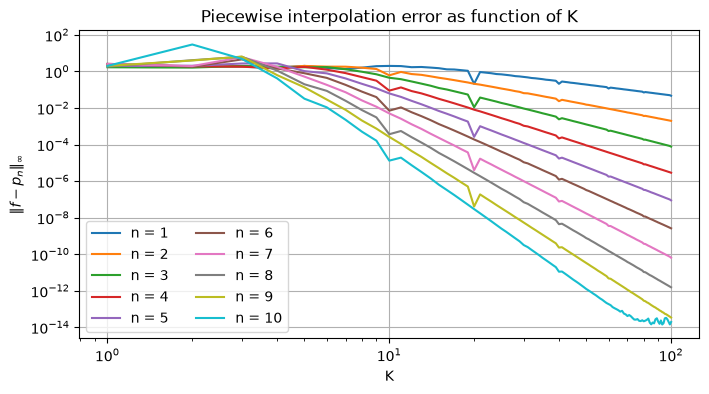

In [10]:
interval_c = (-5.0, 5.0)
grid_c = np.linspace(*interval_c, 5001)
k_arr_c = np.arange(1, 101, dtype=np.int64)

fig, ax = plt.subplots(figsize = (8, 4))

for n_local in range(1, 11):
    max_err, _ = piecewise_lagrange_k(
        fun = f,
        x = grid_c,
        k_arr = k_arr_c,
        n = n_local,
        interval = interval_c,
    )
    
    ax.plot(k_arr_c, max_err, label = f'n = {n_local}', markersize = 3)
    
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('K')
ax.set_ylabel(r'$\|f-p_n\|_\infty$')
ax.set_title('Piecewise interpolation error as function of K')
ax.grid()
ax.legend(ncol = 2) 

plt.show()

 note dips

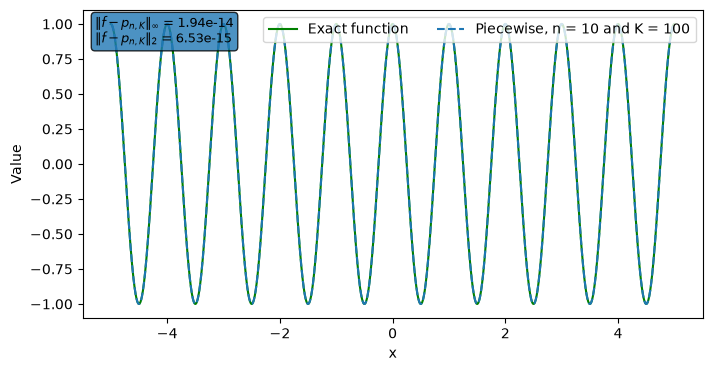

In [11]:
fig, ax = plot_piecewise_interpolation(
    fun = f,
    x = grid_c,
    k = 100,
    n = 10,
    interval = interval_c,
    savefig = SAVE_FIGURES,
)

 interpolation plot

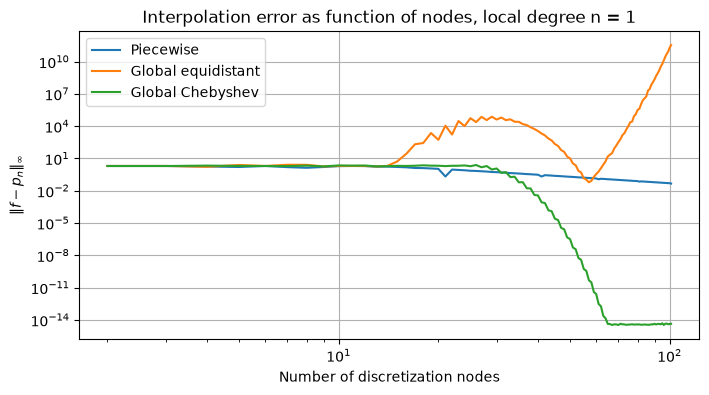

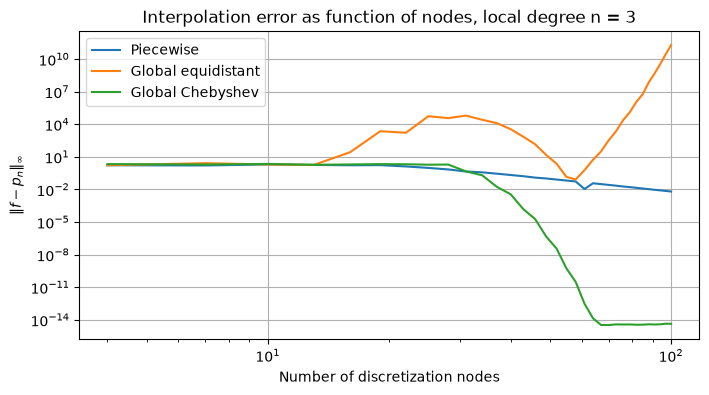

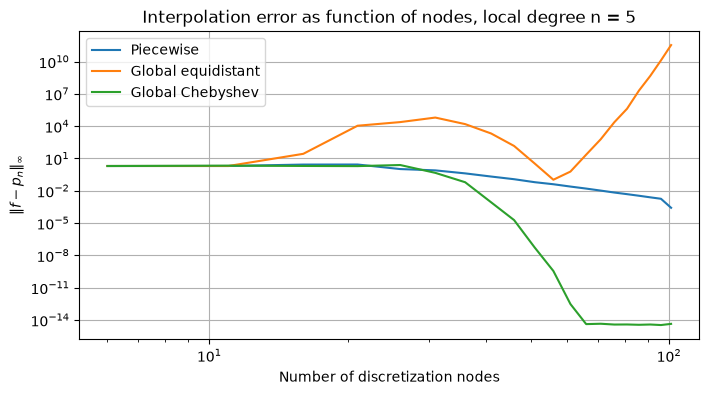

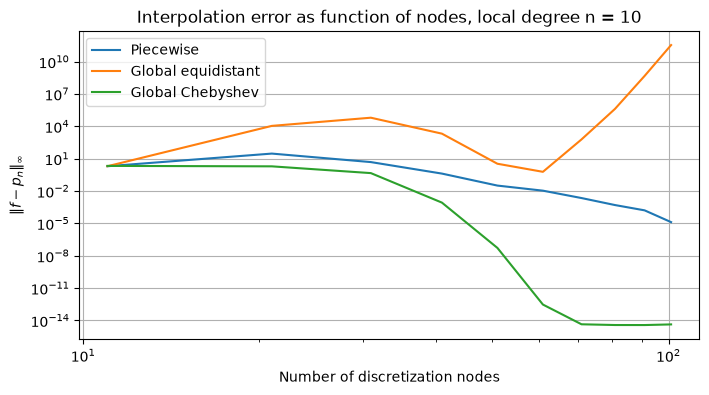

In [12]:
n_arr_comparison = np.array([1, 3, 5, 10], dtype = np.int64)
k_arr_comparison = np.array([1, 2, 4, 8, 16, 34], dtype = np.int64) 
max_degree = 100


for n in n_arr_comparison:
    k_arr = np.arange(1, max_degree// int(n) + 1, dtype = np.int64)
    fig, ax = compare_piecewise_global_max_error(
        fun = f,
        x = grid_c,
        k_arr = k_arr,
        n = n,
        interval = interval_c,
        savefig = SAVE_FIGURES,
    )
plt.show()

 check chebyshev error, sus?

 maximal possible nodes for given n and k

 add piecewise for different n?

Add explanaiton of for n^2 vs for a^2*b. E.g. degree 99 gives 100^2, while 10 sub intervals gives 10^2*10 = 1000

In [13]:
k_arr_runtime = np.array([1, 2, 4, 8, 16, 32], dtype = np.int64)

runtime_result = interpolation_runtime_comparison(
    fun = f,
    x = grid_c,
    interval = interval_c,
    n = 3,
    k_arr = k_arr_runtime,
    repeats = 20,
)

# AI formating
print(
    f"{'Nodes':>8}"
    f"{'Global median':>18}"
    f"{'Piecewise median':>20}"
    f"{'Global std':>15}"
    f"{'Piecewise std':>17}"
)

for nodes, global_time, piecewise_time, global_std, piecewise_std in zip(
    runtime_result["num_nodes"],
    runtime_result["global_median_time"],
    runtime_result["piecewise_median_time"],
    runtime_result["global_std_time"],
    runtime_result["piecewise_std_time"],
):
    print(
        f"{nodes:8d}"
        f"{global_time:18.6e}"
        f"{piecewise_time:20.6e}"
        f"{global_std:15.2e}"
        f"{piecewise_std:17.2e}"
    )
# AI formating

   Nodes     Global median    Piecewise median     Global std    Piecewise std
       4      7.220850e-05        8.989600e-05       9.94e-05         5.88e-05
       7      2.026455e-04        1.150000e-04       8.81e-06         3.21e-05
      13      6.749790e-04        1.779795e-04       1.59e-04         3.63e-05
      25      2.446937e-03        3.001875e-04       9.16e-05         1.21e-05
      49      9.357291e-03        5.370625e-04       1.38e-04         1.02e-05
      97      3.639310e-02        1.038126e-03       4.35e-04         2.91e-05


Plot more ns?

chebyshev 6x faster computaitonally

piecewise 6 ganger så raskt som chebi, begge like bra. Fordi chebi konvergerer omtrent 6 ganger raskere

# d) Radial basis function interpolation

In [14]:
from tma4215_project1.analysis.computations.rbf_computations import (
    rbf_error_epsilon,
)
from tma4215_project1.analysis.plots.rbf_plots import (
    plot_cond_M,
    plot_rbf_error_epsilon,
    plot_rbf_error_condition,
    plot_rbf_interpolation,
)
from tma4215_project1.interpolation.methods import rbf
from tma4215_project1.interpolation.nodes import (
    generate_equidistant_nodes,
)
from tma4215_project1.analysis.computations.rbf_computations import cond_M

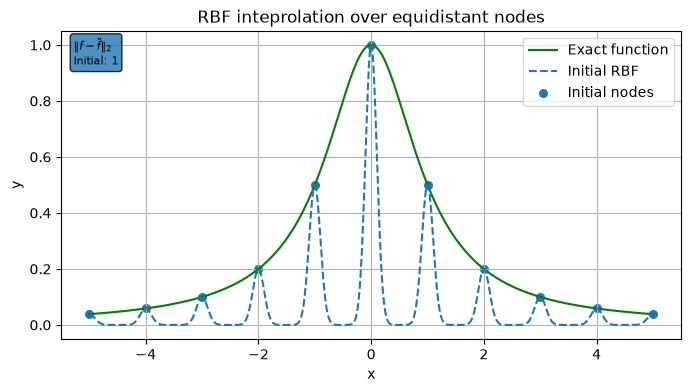

In [15]:
interval_d = (-5.0, 5.0)
n_d = 10
grid_d = np.linspace(*interval_d, 5001)


fig, ax = plot_rbf_interpolation(
    fun = runge,
    n = n_d,
    interval = interval_d,
    init_epsilon = 7,
    N = 1000,
    max_iter = 100,
    max_backtracks = 100,
    tol = 1e-6,
    L = 100.0,
    rho = 0.5,
    rho_bar = 2.0,
    epsilon_min = 1e-4,
    include_optimized = False,
    savefig = SAVE_FIGURES,
)
plt.show()

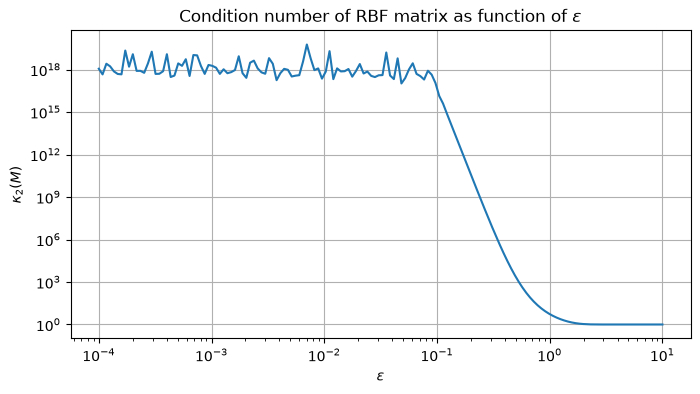

In [16]:

nodes_d = generate_equidistant_nodes(interval_d, n_d)
epsilon_arr_d = np.logspace(-4, 1, 150)


fig, ax = plot_cond_M(
    x_nodes = nodes_d,
    epsilon_arr = epsilon_arr_d,
    savefig = SAVE_FIGURES,
)

plt.show()

log(cond) num gives how many digits you lose in representation

add which epsilons that diverge

 some epsilon give singular matrix thus singular points?

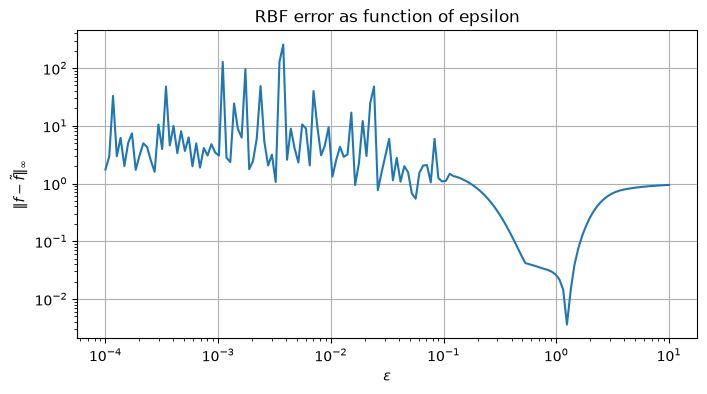

Selected epsilon: 1.24154
Maximum error: 0.00360944
L2 error: 0.00361263


In [17]:
fig, ax = plot_rbf_error_epsilon(
    fun = runge,
    x_nodes = nodes_d,
    x = grid_d,
    interval = interval_d,
    epsilon_arr = epsilon_arr_d,
    savefig = SAVE_FIGURES,
)
plt.show()

runge_max_errors, runge_l2_errors = rbf_error_epsilon(
    fun = runge,
    x_nodes = nodes_d,
    x = grid_d,
    interval = interval_d,
    epsilon_arr = epsilon_arr_d,
)
best_index = int(np.argmin(runge_max_errors))
best_epsilon_d = float(epsilon_arr_d[best_index])

print(f'Selected epsilon: {best_epsilon_d:.6g}')
print(F'Maximum error: {runge_max_errors[best_index]:.6g}')
print(f'L2 error: {runge_l2_errors[best_index]:.6g}')

In [18]:
_, condition_numbers = cond_M(x_nodes = nodes_d, epsilon_arr = epsilon_arr_d)

epsilon_targets = [0.001, 0.01, 0.1, 0.15, 0.5, 1.24, 7.0]

print(
    f"{'Epsilon':>12}"
    f"{'Condition number':>20}"
    f"{'Max error':>16}"
)

for target in epsilon_targets:
    index = int(np.argmin(np.abs(epsilon_arr_d - target)))

    print( 
        f"{epsilon_arr_d[index]:12.4g}"
        f"{condition_numbers[index]:20.4e}"
        f"{runge_max_errors[index]:16.4e}"
        )

     Epsilon    Condition number       Max error
    0.001016          1.8270e+18      3.0518e+00
     0.01031          7.1316e+17      1.3180e+00
     0.09696          1.1180e+17      1.0820e+00
      0.1541          7.4164e+12      1.1325e+00
      0.4912          2.9611e+03      5.5704e-02
       1.242          2.4017e+00      3.6094e-03
       6.795          1.0000e+00      9.0197e-01


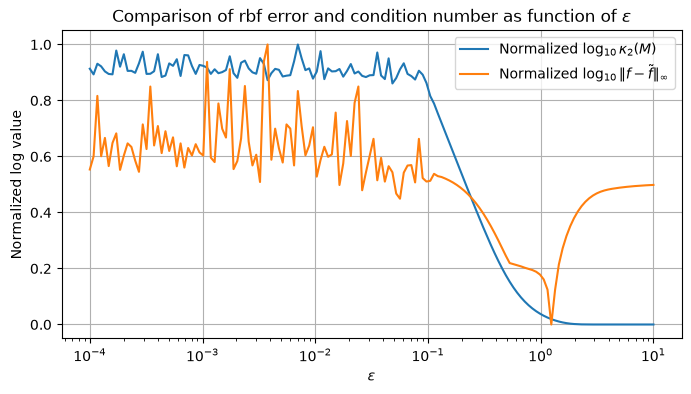

In [19]:
fig, ax = plot_rbf_error_condition(
    fun = runge,
    x_nodes = nodes_d,
    x = grid_d,
    interval = interval_d,
    epsilon_arr = epsilon_arr_d,
    savefig = SAVE_FIGURES,
)
plt.show()

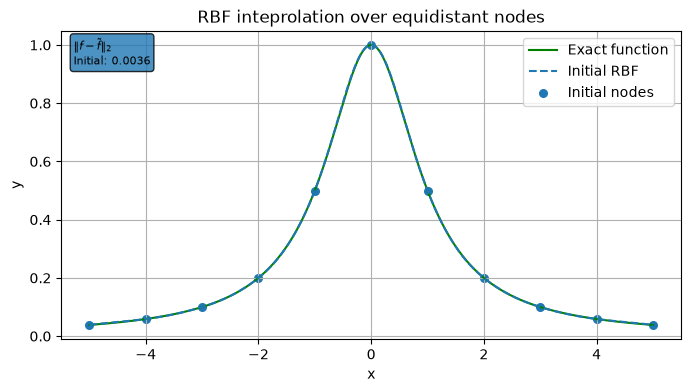

In [20]:
fig, ax = plot_rbf_interpolation(
    fun = runge,
    n = n_d,
    interval = interval_d,
    init_epsilon = best_epsilon_d,
    N = 1000,
    max_iter = 100,
    max_backtracks = 100,
    tol = 1e-6,
    L = 100.0,
    rho = 0.5,
    rho_bar = 2.0,
    epsilon_min = 1e-4,
    include_optimized = False,
    savefig = SAVE_FIGURES,
)
plt.show()

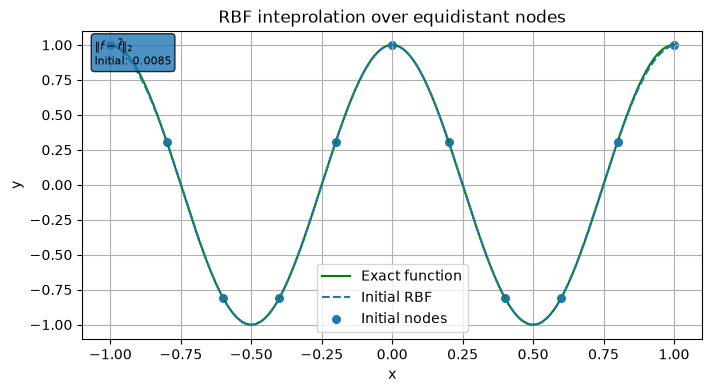

In [21]:
fig, ax = plot_rbf_interpolation(
    fun = f,
    n = 10,
    interval = (-1.0, 1.0),
    init_epsilon = 3.0,
    N = 1000,
    max_iter = 100,
    max_backtracks = 100,
    tol = 1e-6,
    L = 100.0,
    rho = 0.5,
    rho_bar = 2.0,
    epsilon_min = 1e-4,
    include_optimized = False,
    savefig = SAVE_FIGURES,
)
plt.show()

 move higher

 jeg og freddy får forskjellige best epsilon

 SUS! for bra svar

# e) Optimal RBF nodes and shapre parameter

In [22]:
import autograd.numpy as anp
from autograd import grad

from tma4215_project1.analysis.plots.rbf_plots import(
    plot_cost_history_L,
    plot_rbf_compare_n,
    plot_rbf_interpolation,
)
from tma4215_project1.interpolation.nodes import (
    generate_equidistant_nodes,
    make_cost,
)

In [23]:
interval_e = (-5.0, 5.0)
n_e = 10
N_e = 1000
init_epsilon_e = 1.0
epsilon_min_e = 1e-4
max_iter_e = 100
max_backtracks_e = 100
tol_e = 1e-6
rho_e = 0.5
rho_bar_e = 2.0

In [24]:
initial_nodes_e = generate_equidistant_nodes(interval = interval_e, n = n_e)
z_initial_e = anp.concatenate((initial_nodes_e, anp.array([init_epsilon_e])))
cost_e = make_cost(runge, interval_e, N_e)
initial_gradient_e = np.asarray(grad(cost_e)(z_initial_e), dtype = np.float64)

print(f'Initial gradient: {initial_gradient_e}')
print(f'All entries finite: {np.all(np.isfinite(initial_gradient_e))}')

Initial gradient: [ 3.09418976e-05 -1.59488909e-04  1.64087950e-04 -1.37094358e-03
  1.01751924e-03 -8.67555217e-18 -1.01751924e-03  1.37094358e-03
 -1.64087950e-04  1.59488909e-04 -3.09418976e-05 -6.16590328e-03]
All entries finite: True


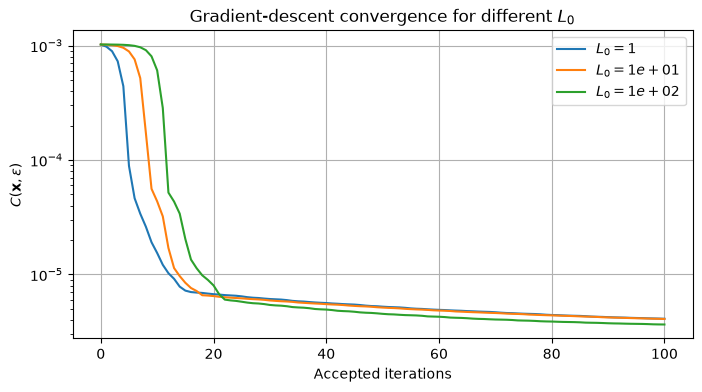

In [25]:
L_arr = np.array([1.0, 10.0, 100.0])

fig, ax = plot_cost_history_L(
    fun = runge,
    n = n_e,
    interval = interval_e,
    init_epsilon = init_epsilon_e,
    N = N_e,
    max_iter = max_iter_e,
    max_backtracks = max_backtracks_e,
    tol = tol_e,
    L_arr = L_arr,
    rho = rho_e,
    rho_bar = rho_bar_e,
    epsilon_min = epsilon_min_e,
    savefig = SAVE_FIGURES
)

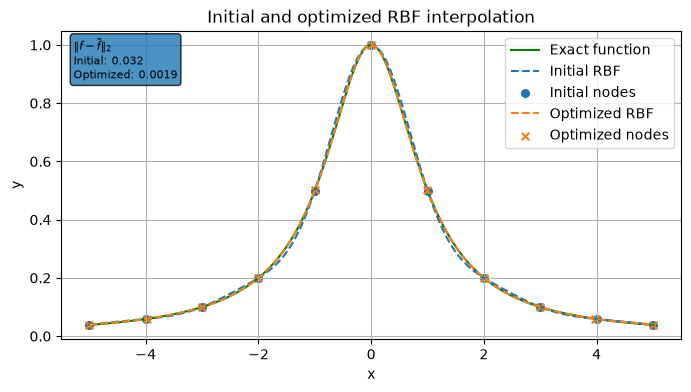

In [26]:
fig, ax = plot_rbf_interpolation(
    fun = runge,
    n = n_e,
    interval = interval_e,
    init_epsilon = init_epsilon_e,
    N = N_e,
    max_iter = max_iter_e,
    max_backtracks = max_backtracks_e,
    tol = tol_e,
    L = 100.0,
    rho = rho_e,
    rho_bar = rho_bar_e,
    epsilon_min = epsilon_min_e,
    savefig = SAVE_FIGURES, 
    include_optimized = True,
)

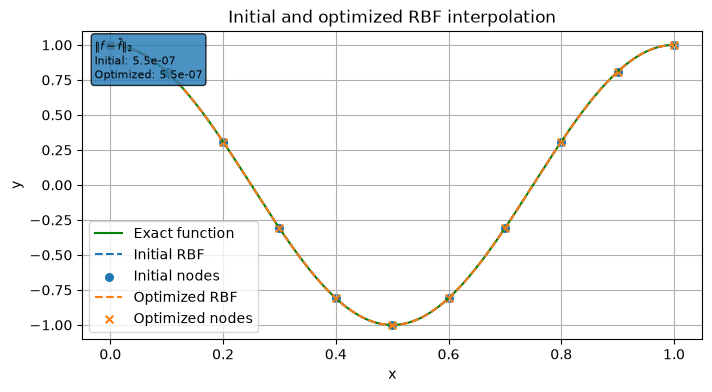

In [27]:
fig, ax = plot_rbf_interpolation(
    fun = f,
    n = n_e,
    interval = (0, 1.0),
    init_epsilon = init_epsilon_e,
    N = N_e,
    max_iter = max_iter_e,
    max_backtracks = max_backtracks_e,
    tol = tol_e,
    L = 100.0,
    rho = rho_e,
    rho_bar = rho_bar_e,
    epsilon_min = epsilon_min_e,
    savefig = SAVE_FIGURES, 
    include_optimized = True,
)

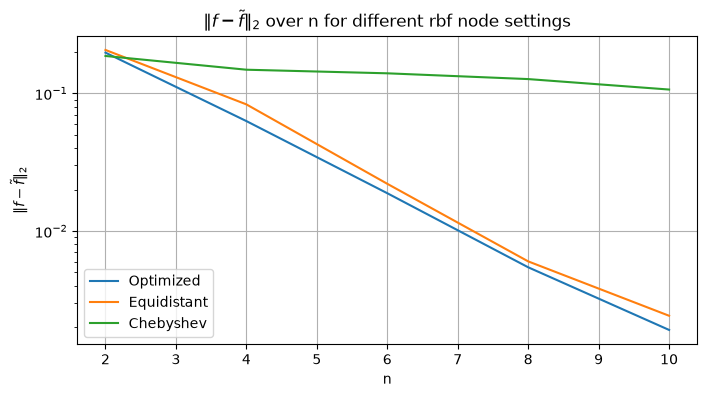

In [28]:
n_arr_e = np.array([2, 4, 6, 8, 10], dtype = np.int64)

fig, ax = plot_rbf_compare_n(
    fun = runge,
    n_arr = n_arr_e,
    interval = interval_e,
    init_epsilon = init_epsilon_e,
    N = N_e,
    max_iter = max_iter_e,
    max_backtracks = max_backtracks_e,
    tol = tol_e,
    L = 100.0,
    rho = rho_e,
    rho_bar = rho_bar_e,
    epsilon_min = epsilon_min_e,
    savefig = SAVE_FIGURES
)

Epsilon problem, Use optimized or init?

 f) Use that polynomial that approximates function best exists and is unique theorem. Weierstrass theorem